In [1]:
 
from datetime import datetime
import sys
import os
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
# Paths
current_dir = os.getcwd()
utilities_dir = os.path.join(current_dir, '../../utilities')
os.chdir(current_dir)
sys.path.insert(0, utilities_dir)

# Import modules
from analytical_solution_functions import sound_hard_circle_calc, mask_displacement
from bem_solution_functions import Circle_n, solveExteriorBoundary, solveExterior, generateInteriorPoints_excluding_circle
import plotting_functions

output_dir = "figs_k"
os.makedirs(output_dir, exist_ok=True)

In [25]:
#%% ======================== PARAMETERS ========================

# Geometry
r_exclude = np.pi / 4
l_se = np.pi
n_dom = 40
n_grid = 501

# Wavenumber study
k_values = np.linspace(1, 10, 10)
bem_k_values = np.linspace(1, 10, 10)
l2_errors = []

# Grid (same for all k)
Y, X = np.mgrid[-l_se:l_se:n_grid*1j, -l_se:l_se:n_grid*1j]
R_grid = np.sqrt(X**2 + Y**2)

# Interior points
points_outside, _ = generateInteriorPoints_excluding_circle(
    Nx=n_dom, Ny=n_dom,
    xmin=-l_se, xmax=l_se,
    ymin=-l_se, ymax=l_se,
    r_exclude=r_exclude
)
interiorIncidentPhi = np.zeros(points_outside.shape[0], dtype=complex)


In [26]:
#%% ======================== LOOP OVER k ========================

for k in k_values:

    print(f"\nSolving for k = {k:.2f}")

    # ------------------ Adaptive discretization ------------------
    n = int(10 * k)   # points per wavelength (important!)
    aVertex, aElement = Circle_n(n=n, radius=r_exclude)

    num_elements = aElement.shape[0]
    aCenters = 0.5 * (aVertex[aElement[:, 0]] + aVertex[aElement[:, 1]])
    theta = np.arctan2(aCenters[:, 1], aCenters[:, 0])

    # ------------------ Boundary conditions ------------------
    alpha = np.zeros(num_elements, dtype=complex)
    beta  = np.ones(num_elements, dtype=complex)

    kx = k * aCenters[:, 0]
    phi_inc = np.exp(1j * kx)
    f = -1j * k * np.cos(theta) * phi_inc

    phi = np.zeros(num_elements, dtype=complex)
    v   = np.zeros(num_elements, dtype=complex)

    # ------------------ Solve BEM ------------------
    c, density = None, None
    v, phi = solveExteriorBoundary(
        k, alpha, beta, f, phi, v,
        aVertex, aElement,
        c, density,
        'exterior'
    )

    # ------------------ Evaluate field ------------------
    interiorPhi = solveExterior(
        k, v, phi,
        interiorIncidentPhi,
        points_outside,
        aVertex, aElement,
        'exterior'
    )

    # ------------------ Interpolation ------------------
    grid_z = griddata(points_outside, interiorPhi, (X, Y), method='cubic')
    grid_z = np.ma.masked_where(R_grid < r_exclude, grid_z)

    u_scn_amp = grid_z.real

    # ------------------ Analytical solution ------------------
    _, u_scn_exact, _ = sound_hard_circle_calc(k, r_exclude, X, Y)
    u_scn_exact = mask_displacement(R_grid, r_exclude, l_se, u_scn_exact)

    # ------------------ L2 error ------------------
    u_exact_masked = np.copy(u_scn_exact)
    u_num_masked   = np.copy(u_scn_amp)

    u_exact_masked[R_grid < r_exclude] = 0
    u_num_masked[R_grid < r_exclude] = 0

    rel_L2 = np.linalg.norm(u_exact_masked.real - u_num_masked.real, 2) / \
             np.linalg.norm(u_exact_masked.real, 2)

    print(f"k = {k:.2f}, L2 error = {rel_L2:.3e}")

    l2_errors.append(rel_L2)

    # ------------------ Error map ------------------
    error_map = np.abs(u_exact_masked.real - u_num_masked.real)

    # ------------------ Plot ------------------
    fig, axs = plt.subplots(1, 3, figsize=(8, 3))

    # --- Numerical solution ---
    im0 = axs[0].imshow(
        u_scn_amp,
        extent=[X.min(), X.max(), Y.min(), Y.max()],
        origin='lower',
        vmin=np.min(u_scn_amp), vmax=np.max(u_scn_amp),
        cmap='twilight_shifted',
    )
    axs[0].set_title(f'BEM (k={k:.2f})', fontsize=8)
    plt.colorbar(im0, ax=axs[0], shrink=0.6)

    # --- Exact solution ---
    im1 = axs[1].imshow(
        u_scn_exact.real,
        extent=[X.min(), X.max(), Y.min(), Y.max()],
        origin='lower',
        vmin=np.min(u_scn_exact.real), vmax=np.max(u_scn_exact.real),
        cmap='twilight_shifted',
    )
    axs[1].set_title(f'Exact (k={k:.2f})', fontsize=8)
    plt.colorbar(im1, ax=axs[1], shrink=0.6)

    # --- Error map ---
    im2 = axs[2].imshow(
        error_map,
        extent=[X.min(), X.max(), Y.min(), Y.max()],
        origin='lower',
        vmin=0, vmax=np.max(error_map),
        cmap='magma',
    )
    axs[2].set_title(f'Error - L2 = {rel_L2:.2e}', fontsize=8)
    plt.colorbar(im2, ax=axs[2], shrink=0.6)
 

    plt.tight_layout()

    # ------------------ Save figure ------------------
    filename = os.path.join(output_dir, f"k_{k:.2f}.png")
    plt.savefig(filename, dpi=300, bbox_inches='tight')

    plt.close(fig)   

date_str = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
np.save(f"data/bem_L2_errors_wavenumbers_{date_str}.npy", np.array(l2_errors))



Solving for k = 1.00
k = 1.00, L2 error = 3.312e-02

Solving for k = 2.00
k = 2.00, L2 error = 2.079e-02

Solving for k = 3.00
k = 3.00, L2 error = 2.476e-02

Solving for k = 4.00
k = 4.00, L2 error = 2.059e-02

Solving for k = 5.00
k = 5.00, L2 error = 2.403e-02

Solving for k = 6.00
k = 6.00, L2 error = 3.139e-02

Solving for k = 7.00
k = 7.00, L2 error = 3.223e-02

Solving for k = 8.00
k = 8.00, L2 error = 3.439e-02

Solving for k = 9.00
k = 9.00, L2 error = 6.605e-02

Solving for k = 10.00
k = 10.00, L2 error = 8.966e-02


In [3]:
l2_errors = np.load("data/bem_L2_errors_wavenumbers_2026-04-07_10-52-08.npy")


/tmp/ipykernel_1920/3826677792.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


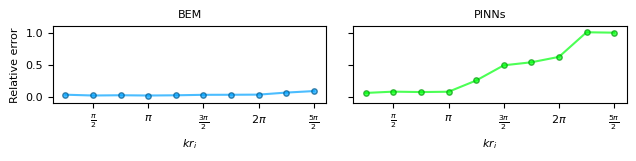

In [5]:
# load BEM data
bem_k_values = np.linspace(1, 10, 10) * np.pi / 4
pinns_k_values = np.linspace(1, 10, 10) * np.pi / 4

k_vals = np.array([2, 4, 6, 8, 10])
k_vals_scaled = k_vals * np.pi / 4
k_labels = [
    r"$\frac{\pi}{2}$",   # 2π/4
    r"$\pi$",             # 4π/4
    r"$\frac{3\pi}{2}$",  # 6π/4
    r"$2\pi$",            # 8π/4
    r"$\frac{5\pi}{2}$"   # 10π/4
]

# Load PINNs data
pinns_l2_errors = np.load("data/pinns_L2_errors_wavenumbers_2026-04-07_16-02-25.npy")
 
fig, axs = plt.subplots(1, 2, figsize=(7.4, 1.0), sharey=True,gridspec_kw={'wspace': 0.1})
    
# -------------------- BEM --------------------
axs[0].plot(bem_k_values, l2_errors, color="#00a2ff", alpha=0.7, zorder=1)
axs[0].scatter(bem_k_values, l2_errors, s=15, color="#00a2ff", alpha=0.7,
               edgecolor="#00578a", zorder=2)

axs[0].set_xlabel("$k r_{i}$")
axs[0].set_ylabel("Relative error")
axs[0].set_xticks(k_vals_scaled)
axs[0].set_xticklabels(k_labels)
axs[0].set_ylim(-0.1, 1.1)
axs[0].set_title("BEM", fontsize=8)

# -------------------- PINNs --------------------
axs[1].plot(pinns_k_values, pinns_l2_errors, color="#00ff0d", alpha=0.7, zorder=1)
axs[1].scatter(pinns_k_values, pinns_l2_errors, s=15, color="#00ff0d", alpha=0.7,
               edgecolor="#009908", zorder=2)

axs[1].set_xlabel("$k r_{i}$")
axs[1].set_xticks(k_vals_scaled)
axs[1].set_xticklabels(k_labels)
axs[1].set_title("PINNs", fontsize=8)

# -------------------- Layout --------------------
plt.tight_layout()

os.makedirs("figures", exist_ok=True)
plt.savefig("figures/bem_vs_pinns_L2_vs_k.svg", dpi=300, bbox_inches='tight')
plt.show()

In [43]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import glob
import os

# -------- Sort correctly by k value --------
image_files = sorted(
    glob.glob(os.path.join(output_dir, "k_*.png")),
    key=lambda x: float(os.path.basename(x).split("_")[1].replace(".png", ""))
)

n = len(image_files)

fig, axs = plt.subplots(n, 1, figsize=(6, 1.5*n))

if n == 1:
    axs = [axs]

for ax, img_path in zip(axs, image_files):
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, f"BEM_vertical_{date_str}.pdf"), dpi=300)
plt.close(fig)